# Learning digit recognition from addition labels

This notebook trains a digit classifier without using any labeled digits. The only supervision during training comes from pairs of images and their sum. This example is based on the DeepProbLog paper (Manhaeve et al., 2018).

By the end of this notebook, we will have seen:

1. How to express an existential constraint over a pair of predicates
2. How indirect, logic-based supervision can train a model without direct labels
3. How the result compares to a supervised baseline

## Preliminaries

To get started, let us first get the standard preambles out of the way. We need a bunch of imports. (The `torchvision` library is not part of `pysignet`'s dependencies, and will need to be installed separately.)

In [1]:
%pip install torchvision -q -q

Note: you may need to restart the kernel to use updated packages.


In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import pysignet as psn

## The setup

During training, the model sees pairs of MNIST images and their sum. It never sees an individual digit label. The task is to learn digit classification from this indirect supervision alone.

## The dataset

Each example stores two images and their sum. Individual digit labels are kept only for evaluation; the training loop never uses them.

In [3]:
class MNISTAdditionDataset(Dataset):
    """Dataset of MNIST image pairs with their sums."""
    
    def __init__(self, mnist_dataset, n_pairs: int = 10000):
        self.mnist = mnist_dataset
        self.n_pairs = n_pairs
        
        # Pre-generate random pairs
        self.indices = torch.randint(0, len(mnist_dataset), (n_pairs, 2))
    
    def __len__(self):
        return self.n_pairs
    
    def __getitem__(self, idx):
        idx1, idx2 = self.indices[idx]
        
        img1, label1 = self.mnist[idx1]
        img2, label2 = self.mnist[idx2]
        
        # The sum is our only supervision signal
        sum_label = label1 + label2
        
        return {
            "img1": img1,
            "img2": img2,
            "sum": sum_label,
            "label1": label1,  # Only for evaluation
            "label2": label2,  # Only for evaluation
        }

In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.manual_seed(42)

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,)),
    transforms.Lambda(lambda x: x.view(-1))  # Flatten to 784
])

transform_viz = transforms.Compose([
    transforms.ToTensor(),
])

train_mnist = datasets.MNIST('./data', train=True, download=True, transform=transform)
test_mnist = datasets.MNIST('./data', train=False, transform=transform)
viz_mnist = datasets.MNIST('./data', train=False, transform=transform_viz)

train_dataset = MNISTAdditionDataset(train_mnist, n_pairs=30000)
test_dataset = MNISTAdditionDataset(test_mnist, n_pairs=5000)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=256, shuffle=False)

print(f"Training pairs: {len(train_dataset)}")
print(f"Test pairs:     {len(test_dataset)}")
print(f"Device:         {device}")

Training pairs: 30000
Test pairs:     5000
Device:         cpu


## The data

Let us look at some training examples. The model sees only the sum shown beneath each pair.

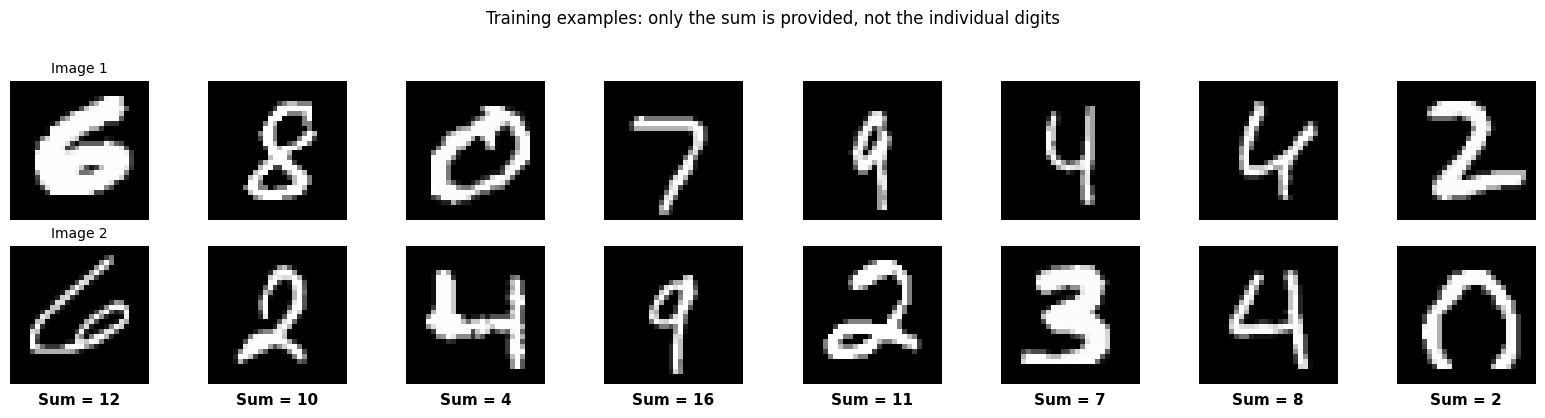

In [5]:
def show_addition_examples(dataset, viz_dataset, n_examples=8):
    """Display example image pairs with their sums."""
    fig, axes = plt.subplots(2, n_examples, figsize=(n_examples * 2, 4))
    
    for i in range(n_examples):
        sample = dataset[i]
        idx1, idx2 = dataset.indices[i]
        
        # Get original images for visualization
        img1, _ = viz_dataset[idx1]
        img2, _ = viz_dataset[idx2]
        
        axes[0, i].imshow(img1.squeeze(), cmap='gray')
        axes[0, i].axis('off')
        if i == 0:
            axes[0, i].set_title('Image 1', fontsize=10)
        
        axes[1, i].imshow(img2.squeeze(), cmap='gray')
        axes[1, i].axis('off')
        if i == 0:
            axes[1, i].set_title('Image 2', fontsize=10)
        
        axes[1, i].text(0.5, -0.15, f"Sum = {sample['sum']}",
                        transform=axes[1, i].transAxes,
                        ha='center', fontsize=11, fontweight='bold')
    
    plt.suptitle('Training examples: only the sum is provided, not the individual digits', 
                 fontsize=12, y=1.02)
    plt.tight_layout()
    plt.show()

viz_train = datasets.MNIST('./data', train=True, transform=transform_viz)
show_addition_examples(train_dataset, viz_train)

The gray labels above each image are the hidden ground truth. The model must infer these from the addition constraint alone.

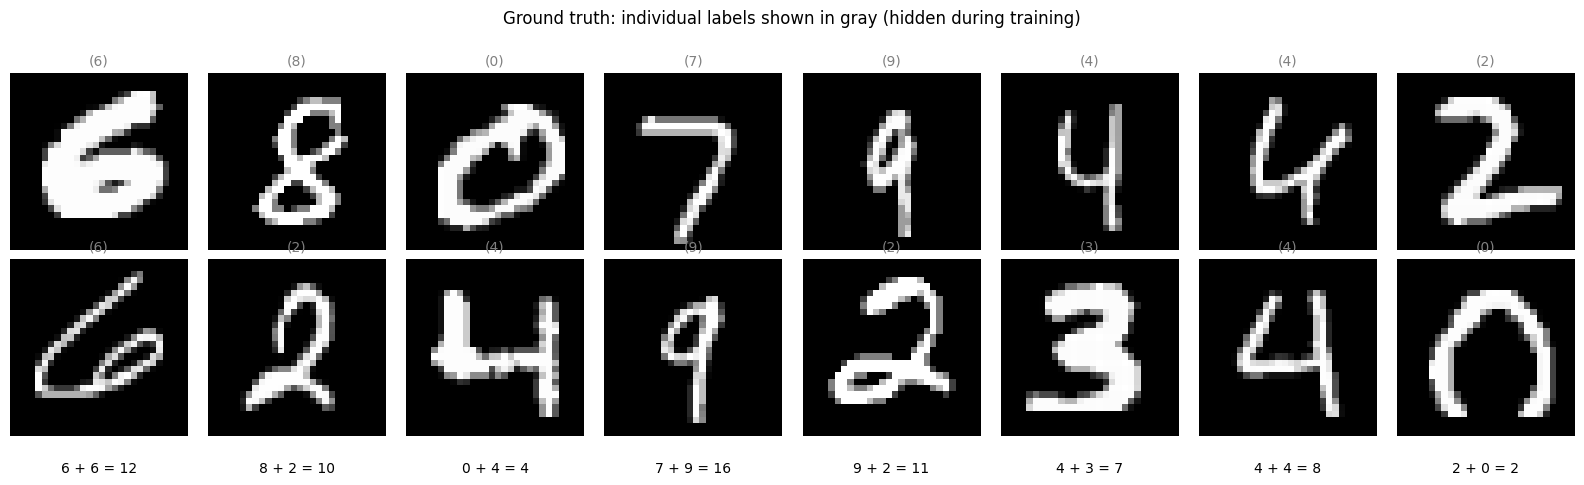

In [6]:
def show_examples_with_labels(dataset, viz_dataset, n_examples=8):
    """Display examples showing both sum and hidden individual labels."""
    fig, axes = plt.subplots(2, n_examples, figsize=(n_examples * 2, 4.5))
    
    for i in range(n_examples):
        sample = dataset[i]
        idx1, idx2 = dataset.indices[i]
        
        img1, _ = viz_dataset[idx1]
        img2, _ = viz_dataset[idx2]
        
        axes[0, i].imshow(img1.squeeze(), cmap='gray')
        axes[0, i].axis('off')
        axes[0, i].set_title(f"({sample['label1']})", fontsize=10, color='gray')
        
        axes[1, i].imshow(img2.squeeze(), cmap='gray')
        axes[1, i].axis('off')
        axes[1, i].set_title(f"({sample['label2']})", fontsize=10, color='gray')
        
        axes[1, i].text(0.5, -0.2, 
                        f"{sample['label1']} + {sample['label2']} = {sample['sum']}",
                        transform=axes[1, i].transAxes,
                        ha='center', fontsize=10)
    
    plt.suptitle('Ground truth: individual labels shown in gray (hidden during training)', 
                 fontsize=12, y=1.02)
    plt.tight_layout()
    plt.show()

show_examples_with_labels(train_dataset, viz_train)

## The model

A simple MLP that outputs class probabilities for digits 0-9. The same architecture is used for the supervised baseline later.

In [7]:
class DigitClassifier(nn.Module):
    def __init__(self, hidden_size: int = 256):
        super().__init__()
        self.fc1 = nn.Linear(784, hidden_size)
        self.fc2 = nn.Linear(hidden_size, 128)
        self.fc3 = nn.Linear(128, 10)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        return self.fc3(x)  # logits

    def predict_probs(self, x: torch.Tensor) -> torch.Tensor:
        return F.softmax(self.forward(x), dim=-1)

model = DigitClassifier().to(device)
print(f"Model parameters: {sum(p.numel() for p in model.parameters()):,}")

Model parameters: 235,146


## The addition constraint

For a pair with true sum S, we want the model to predict some digit i for the first image and S-i for the second. A single `ForAll`-`Implies`-`Exists` captures this for all sums at once:

$$\forall S \in \{0,\ldots,18\}: \text{Sum}(S_\text{actual}, S) \Rightarrow \exists\, i \in \{0,\ldots,9\}: \text{Digit}(X_1, i) \land \text{Digit}(X_2, S{-}i)$$

`Sum` is a deterministic indicator predicate: it returns 1 for batch elements whose true sum equals S, and 0 otherwise. When it is 0, the implication is trivially satisfied, so only the relevant constraint is active for each example.

In [8]:
Sum = psn.Symbol("Sum")
Digit = psn.Symbol("Digit")
X1, X2, S_actual, S, I = psn.Variable("X1 X2 S_actual S I")

expr = psn.ForAll(S, range(19),
    psn.Implies(
        Sum(S_actual, S),
        psn.Exists(I, range(10), psn.And(Digit(X1, I), Digit(X2, S - I)))
    )
)

## Training

For each batch, we group examples by their sum and apply the corresponding constraint. No digit labels are used.

In [9]:
def evaluate_digit_accuracy(model, mnist_loader):
    """Evaluate digit classification accuracy on standard MNIST."""
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for img, label in mnist_loader:
            img = img.to(device)
            label = label.to(device)
            preds = model(img).argmax(dim=-1)
            correct += (preds == label).sum().item()
            total += len(label)
    return correct / total


def evaluate_addition_accuracy(model, addition_loader):
    """Evaluate whether predicted digits add up correctly."""
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for batch in addition_loader:
            img1 = batch["img1"].to(device)
            img2 = batch["img2"].to(device)
            target_sum = batch["sum"].to(device)
            
            pred1 = model(img1).argmax(dim=-1)
            pred2 = model(img2).argmax(dim=-1)
            pred_sum = pred1 + pred2
            
            correct += (pred_sum == target_sum).sum().item()
            total += len(target_sum)
    return correct / total


# Create data loaders for evaluation
eval_train_loader = DataLoader(
    datasets.MNIST('./data', train=True, transform=transform),
    batch_size=256, shuffle=False
)
eval_test_loader = DataLoader(
    datasets.MNIST('./data', train=False, transform=transform),
    batch_size=256, shuffle=False
)

In [10]:
def digit_pred(model):
    """Return probability of digit_idx for image x. Returns 0 for out-of-range indices."""
    def pred(x, digit_idx):
        probs = model.predict_probs(x)
        if not (0 <= digit_idx <= 9):
            return torch.zeros(probs.shape[0], device=probs.device)
        return probs[:, digit_idx]
    return pred


def train_with_addition(model, train_loader, n_epochs: int = 10, lr: float = 0.001):
    predicates = {
        "Sum": lambda s_actual, s: (s_actual == s).float(),
        "Digit": digit_pred(model),
    }
    loss_fn = psn.logic_to_loss(expr, predicates)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    history = {'loss': [], 'digit_acc': [], 'add_acc': []}

    for epoch in range(n_epochs):
        model.train()
        total_loss = 0.0
        n_batches = 0

        for batch in train_loader:
            img1 = batch["img1"].to(device)
            img2 = batch["img2"].to(device)
            sums = batch["sum"].to(device)

            optimizer.zero_grad()
            loss = loss_fn.loss(X1=img1, X2=img2, S_actual=sums)
            loss.backward()
            optimizer.step()

            total_loss += loss.item()
            n_batches += 1

        avg_loss = total_loss / n_batches
        digit_acc = evaluate_digit_accuracy(model, eval_test_loader)
        add_acc = evaluate_addition_accuracy(model, test_loader)

        history['loss'].append(avg_loss)
        history['digit_acc'].append(digit_acc)
        history['add_acc'].append(add_acc)

        print(f"Epoch {epoch+1:2d}: loss={avg_loss:.4f}, "
              f"digit_acc={digit_acc:.4f}, add_acc={add_acc:.4f}")

    return model, history

In [11]:
# Check initial accuracy (should be approximately 10%, as expected for random guessing)
print("Before training:")
print(f"  Digit accuracy: {evaluate_digit_accuracy(model, eval_test_loader):.4f}")
print(f"  Addition accuracy: {evaluate_addition_accuracy(model, test_loader):.4f}")
print()

Before training:
  Digit accuracy: 0.0895
  Addition accuracy: 0.0576



In [12]:
# Train with addition supervision only
print("Training with addition supervision only...")
print("(No individual digit labels are used!)")
print()
model, history = train_with_addition(model, train_loader, n_epochs=15, lr=0.001)

Training with addition supervision only...
(No individual digit labels are used!)

Epoch  1: loss=44.8680, digit_acc=0.9577, add_acc=0.9230
Epoch  2: loss=12.3952, digit_acc=0.9717, add_acc=0.9434
Epoch  3: loss=6.8875, digit_acc=0.9701, add_acc=0.9436
Epoch  4: loss=4.6780, digit_acc=0.9713, add_acc=0.9476
Epoch  5: loss=3.2644, digit_acc=0.9746, add_acc=0.9508
Epoch  6: loss=2.7228, digit_acc=0.9748, add_acc=0.9532
Epoch  7: loss=2.1660, digit_acc=0.9684, add_acc=0.9400
Epoch  8: loss=2.0839, digit_acc=0.9724, add_acc=0.9514
Epoch  9: loss=1.7026, digit_acc=0.9739, add_acc=0.9518
Epoch 10: loss=1.4992, digit_acc=0.9738, add_acc=0.9540
Epoch 11: loss=1.2517, digit_acc=0.9744, add_acc=0.9520
Epoch 12: loss=1.4177, digit_acc=0.9771, add_acc=0.9568
Epoch 13: loss=1.3020, digit_acc=0.9784, add_acc=0.9602
Epoch 14: loss=0.7812, digit_acc=0.9759, add_acc=0.9574
Epoch 15: loss=1.4190, digit_acc=0.9706, add_acc=0.9430


## Training progress

The left plot shows the constraint loss; the right shows digit accuracy and addition accuracy on the test set.

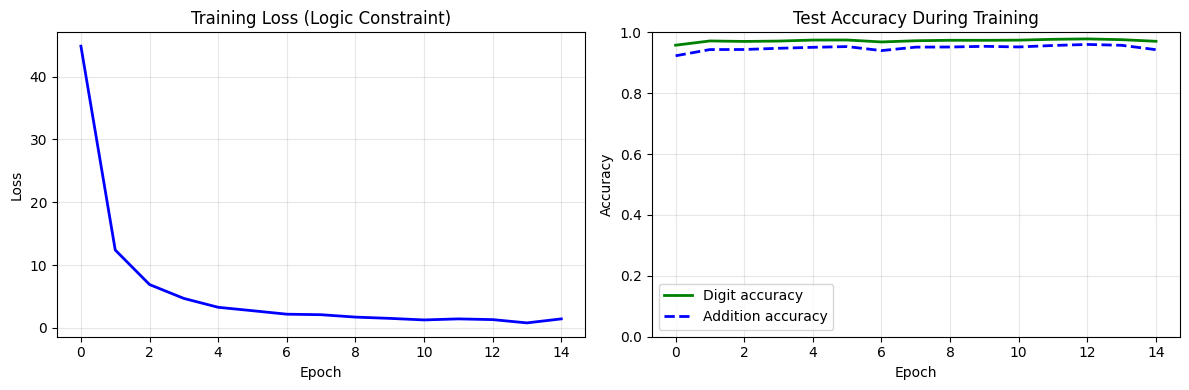

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history['loss'], 'b-', linewidth=2)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training Loss (Logic Constraint)')
axes[0].grid(True, alpha=0.3)

axes[1].plot(history['digit_acc'], 'g-', linewidth=2, label='Digit accuracy')
axes[1].plot(history['add_acc'], 'b--', linewidth=2, label='Addition accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Test Accuracy During Training')
axes[1].legend()
axes[1].grid(True, alpha=0.3)
axes[1].set_ylim(0, 1)

plt.tight_layout()
plt.show()

In [14]:
digit_acc = evaluate_digit_accuracy(model, eval_test_loader)
add_acc = evaluate_addition_accuracy(model, test_loader)
print(f"Digit accuracy:    {digit_acc:.4f}")
print(f"Addition accuracy: {add_acc:.4f}")

Digit accuracy:    0.9706
Addition accuracy: 0.9430


The model learned to classify digits without ever seeing a single digit label during training.

## Predictions

Let us look at some test examples. Correct predictions are shown in green, incorrect in red.

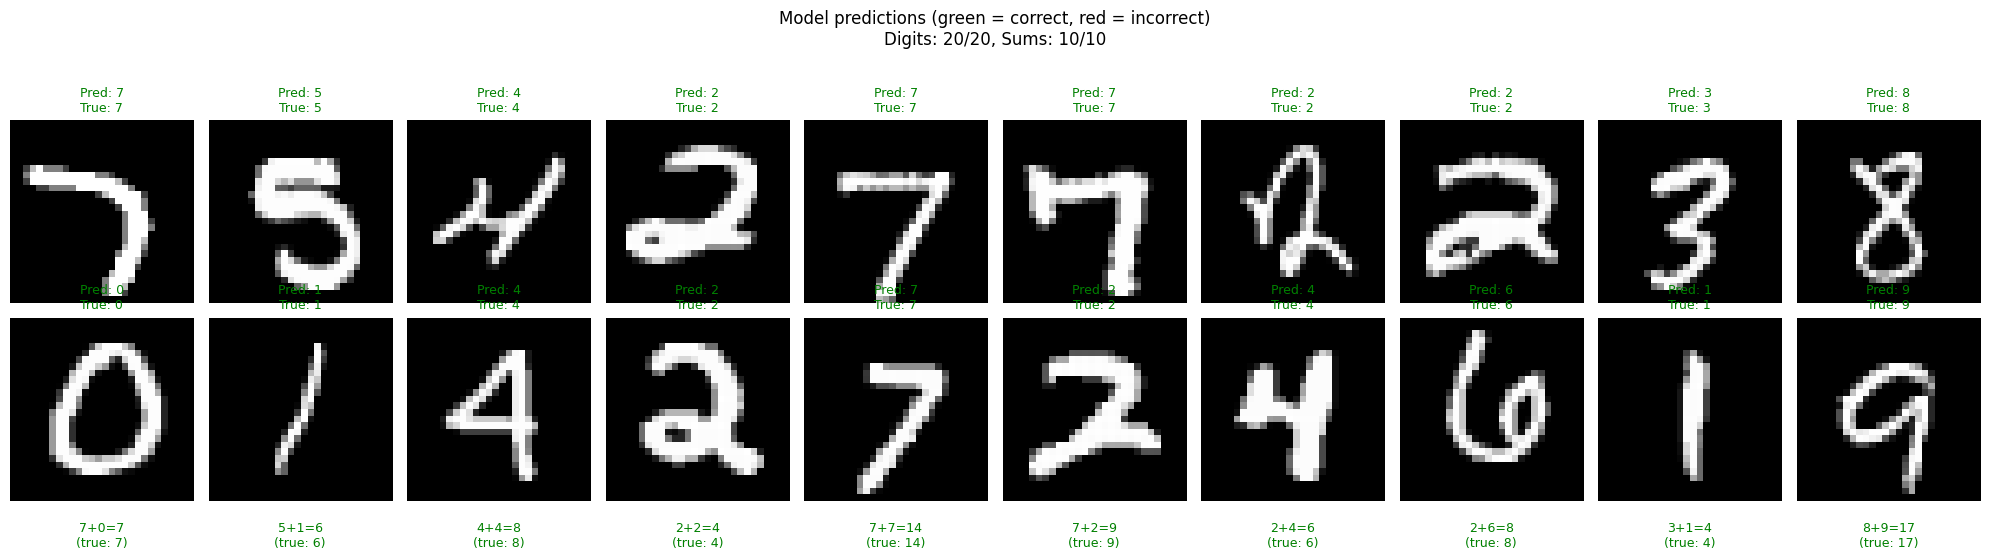

In [15]:
def show_predictions(model, dataset, viz_dataset, n_examples=8):
    """Show model predictions on test examples."""
    model.eval()
    
    fig, axes = plt.subplots(2, n_examples, figsize=(n_examples * 2, 5))
    
    correct_additions = 0
    correct_digits = 0
    
    with torch.no_grad():
        for i in range(n_examples):
            sample = dataset[i]
            idx1, idx2 = dataset.indices[i]
            
            img1 = sample["img1"].unsqueeze(0).to(device)
            img2 = sample["img2"].unsqueeze(0).to(device)
            
            pred1 = model(img1).argmax(dim=-1).item()
            pred2 = model(img2).argmax(dim=-1).item()
            pred_sum = pred1 + pred2
            
            true1, true2 = sample["label1"], sample["label2"]
            true_sum = sample["sum"]
            
            sum_correct = (pred_sum == true_sum)
            d1_correct = (pred1 == true1)
            d2_correct = (pred2 == true2)
            
            if sum_correct:
                correct_additions += 1
            if d1_correct:
                correct_digits += 1
            if d2_correct:
                correct_digits += 1
            
            viz_img1, _ = viz_dataset[idx1]
            viz_img2, _ = viz_dataset[idx2]
            
            axes[0, i].imshow(viz_img1.squeeze(), cmap='gray')
            axes[0, i].axis('off')
            color1 = 'green' if d1_correct else 'red'
            axes[0, i].set_title(f"Pred: {pred1}\nTrue: {true1}", 
                                 fontsize=9, color=color1)
            
            axes[1, i].imshow(viz_img2.squeeze(), cmap='gray')
            axes[1, i].axis('off')
            color2 = 'green' if d2_correct else 'red'
            axes[1, i].set_title(f"Pred: {pred2}\nTrue: {true2}", 
                                 fontsize=9, color=color2)
            
            sum_color = 'green' if sum_correct else 'red'
            axes[1, i].text(0.5, -0.25, 
                           f"{pred1}+{pred2}={pred_sum}\n(true: {true_sum})",
                           transform=axes[1, i].transAxes,
                           ha='center', fontsize=9, color=sum_color)
    
    plt.suptitle(f'Model predictions (green = correct, red = incorrect)\n'
                 f'Digits: {correct_digits}/{n_examples*2}, Sums: {correct_additions}/{n_examples}', 
                 fontsize=12, y=1.05)
    plt.tight_layout()
    plt.show()

viz_test = datasets.MNIST('./data', train=False, transform=transform_viz)
show_predictions(model, test_dataset, viz_test, n_examples=10)

Additional test examples:


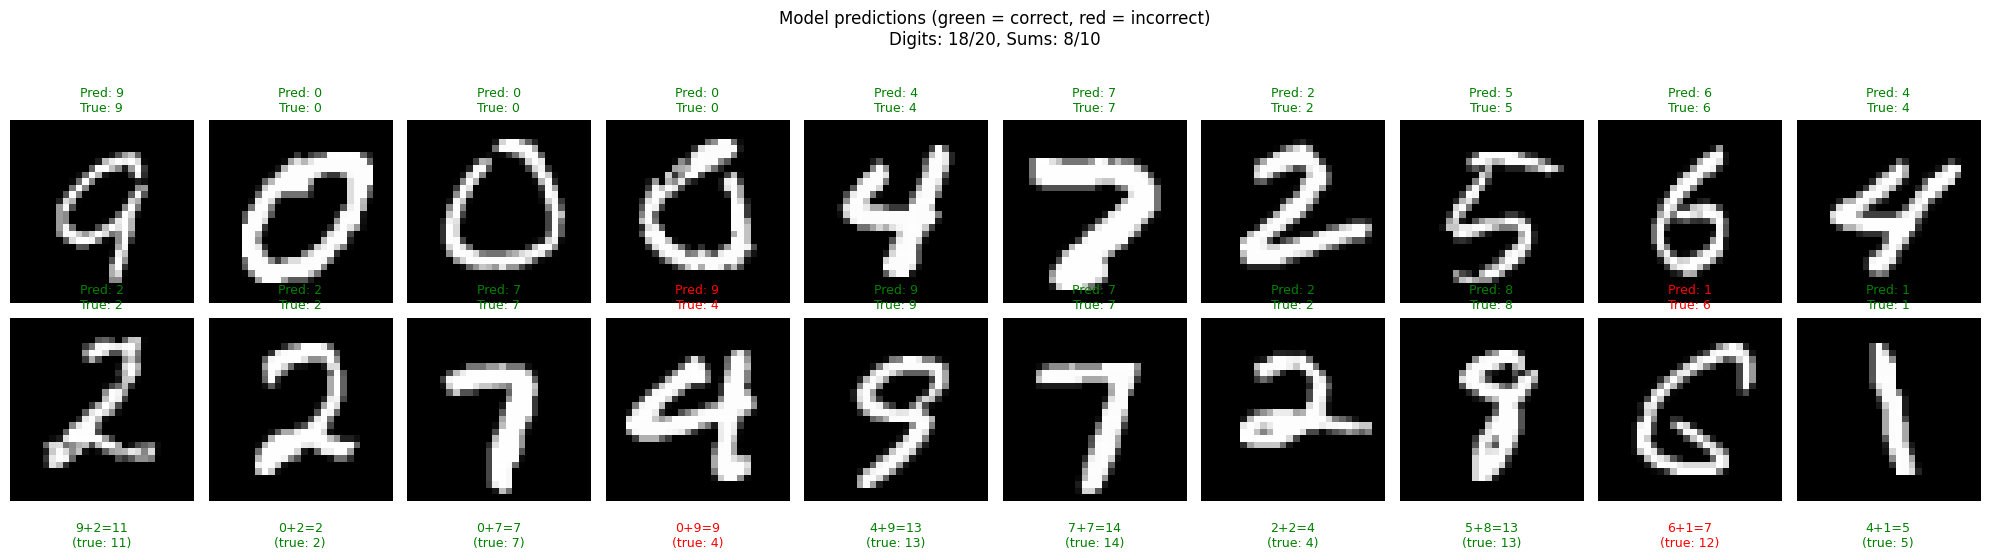

In [16]:
# Show more examples from a different part of the test set
print("Additional test examples:")

class OffsetDataset:
    def __init__(self, base, offset):
        self.base = base
        self.offset = offset
        self.indices = base.indices[offset:offset+100]
    def __getitem__(self, i):
        return self.base[i + self.offset]

show_predictions(model, OffsetDataset(test_dataset, 100), viz_test, n_examples=10)

## Comparison with supervised learning

For reference, here is the same model trained with direct digit labels.

In [ ]:
def train_supervised(n_epochs: int = 5, lr: float = 0.001):
    """Train digit classifier with direct digit supervision."""
    model_sup = DigitClassifier().to(device)
    optimizer = torch.optim.Adam(model_sup.parameters(), lr=lr)

    digit_loss = psn.logic_to_loss(Digit(X1, I), {"Digit": model_sup})

    train_loader_sup = DataLoader(
        datasets.MNIST('./data', train=True, transform=transform),
        batch_size=64, shuffle=True
    )

    for epoch in range(n_epochs):
        model_sup.train()
        for img, label in train_loader_sup:
            img = img.to(device)
            label = label.to(device)

            optimizer.zero_grad()
            digit_loss.loss(X1=img, I=label, quantify="none", reduction="mean").backward()
            optimizer.step()

        acc = evaluate_digit_accuracy(model_sup, eval_test_loader)
        print(f"Epoch {epoch+1}: digit_acc={acc:.4f}")

    return model_sup

print("Training supervised baseline...")
model_supervised = train_supervised(n_epochs=5)

In [18]:
neuro_sym_acc = evaluate_digit_accuracy(model, eval_test_loader)
supervised_acc = evaluate_digit_accuracy(model_supervised, eval_test_loader)

print(f"Neuro-symbolic (addition only):  {neuro_sym_acc:.4f}")
print(f"Supervised (digit labels):       {supervised_acc:.4f}")
print(f"Ratio: {neuro_sym_acc / supervised_acc:.3f}")

Neuro-symbolic (addition only):  0.9706
Supervised (digit labels):       0.9752
Ratio: 0.995


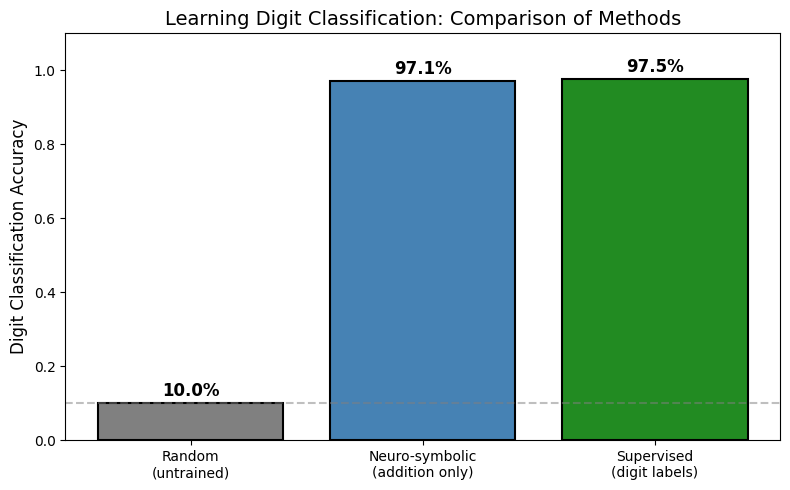

In [19]:
fig, ax = plt.subplots(figsize=(8, 5))

methods = ['Random\n(untrained)', 'Neuro-symbolic\n(addition only)', 'Supervised\n(digit labels)']
accuracies = [0.10, neuro_sym_acc, supervised_acc]
colors = ['gray', 'steelblue', 'forestgreen']

bars = ax.bar(methods, accuracies, color=colors, edgecolor='black', linewidth=1.5)

for bar, acc in zip(bars, accuracies):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f'{acc:.1%}', ha='center', fontsize=12, fontweight='bold')

ax.set_ylabel('Digit Classification Accuracy', fontsize=12)
ax.set_ylim(0, 1.1)
ax.set_title('Learning Digit Classification: Comparison of Methods', fontsize=14)
ax.axhline(y=0.10, color='gray', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()